In [73]:
import numpy as np
import cv2
import numpy as np
import matplotlib.pyplot as plt

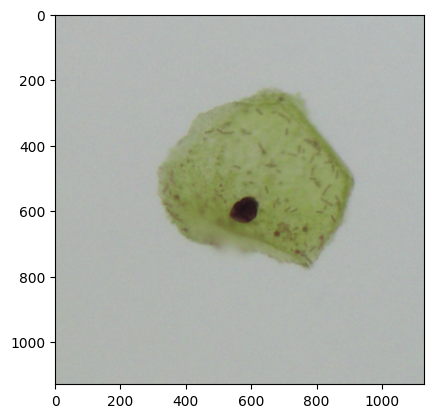

In [74]:
image_path = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\single_all\72b_1.jpg"  # Replace with your image path
image = cv2.imread(image_path)
plt.imshow(image)

In [75]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

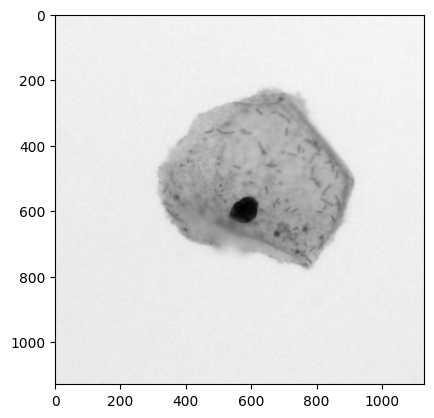

In [76]:
plt.imshow(gray, cmap='gray')

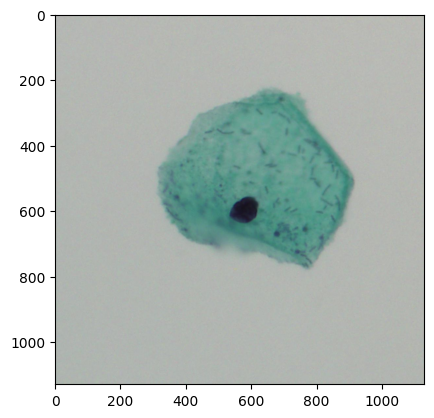

In [77]:
plt.imshow(image_rgb)

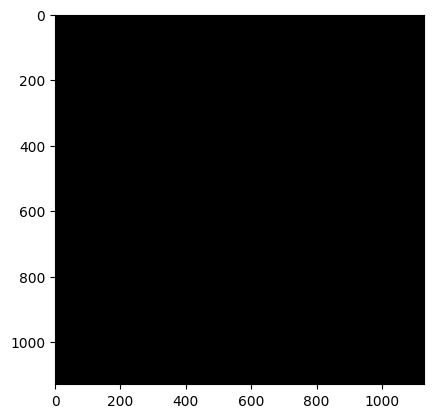

In [78]:
white_mask = cv2.inRange(image_rgb, np.array([220, 220, 220]), np.array([255, 255, 255])) #usuwanie tła
not_white_mask = cv2.bitwise_not(white_mask)
plt.imshow(not_white_mask, cmap='gray')

In [79]:
gray_nonwhite = gray[not_white_mask > 0]

mean_intensity = np.mean(gray_nonwhite)
dynamic_thresh = int(mean_intensity * 0.8)

dark_mask = cv2.inRange(gray, 0, dynamic_thresh)
dark_mask = cv2.bitwise_and(dark_mask, dark_mask, mask=not_white_mask)

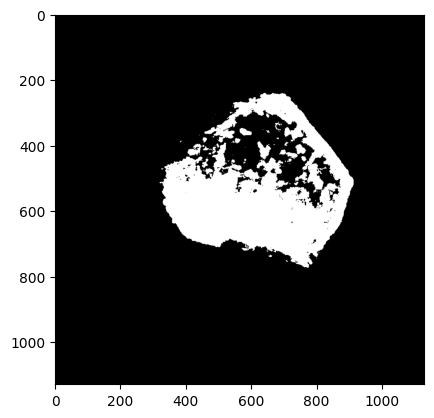

In [80]:
plt.imshow(dark_mask, cmap='gray')

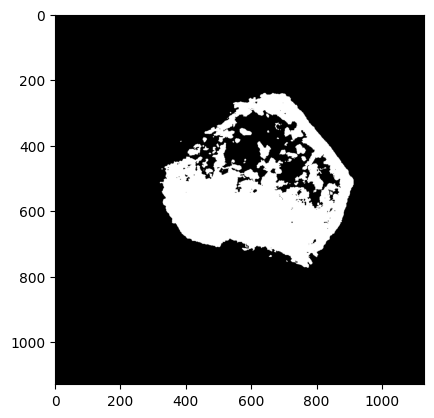

In [81]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
nucleus_clean = cv2.morphologyEx(dark_mask, cv2.MORPH_OPEN, kernel)
plt.imshow(nucleus_clean, cmap='gray')

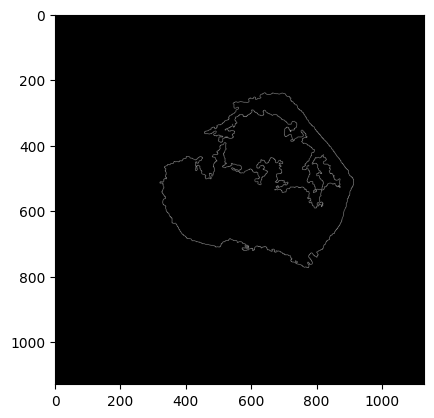

In [82]:
contours_nucleus, _ = cv2.findContours(nucleus_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_nucleus = np.zeros_like(gray)
nucleus_contour_img = np.zeros_like(gray)

if contours_nucleus:
    # Znajdź kontur o NAJNIŻSZEJ średniej jasności → to jądro
    min_intensity = 999
    selected_contour = None

    for cnt in contours_nucleus:
        temp_mask = np.zeros_like(gray)
        cv2.drawContours(temp_mask, [cnt], -1, 255, -1)
        mean_val = np.mean(gray[temp_mask == 255])

        if mean_val < min_intensity:
            min_intensity = mean_val
            selected_contour = cnt

    if selected_contour is not None:
        cv2.drawContours(mask_nucleus, [selected_contour], -1, 255, -1)
        nucleus_contour_img = cv2.Canny(mask_nucleus, 50, 150)

plt.imshow(nucleus_contour_img, cmap='gray')

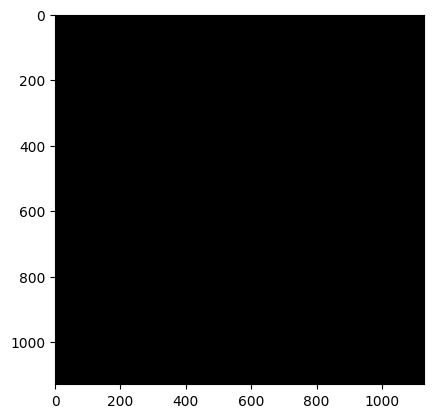

In [83]:
cell_mask = cv2.bitwise_not(white_mask)
plt.imshow(cell_mask, cmap='gray')

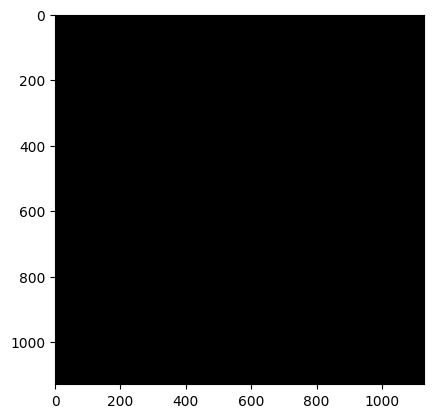

In [84]:
cell_blurred = cv2.GaussianBlur(cell_mask, (3, 3), 0)
plt.imshow(cell_blurred, cmap='gray')

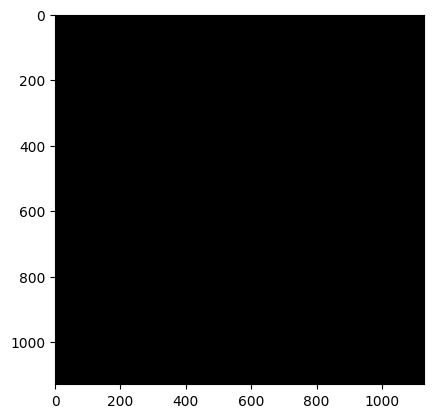

In [85]:
cell_contour = cv2.Canny(cell_blurred, 30, 100)
plt.imshow(cell_contour, cmap='gray')

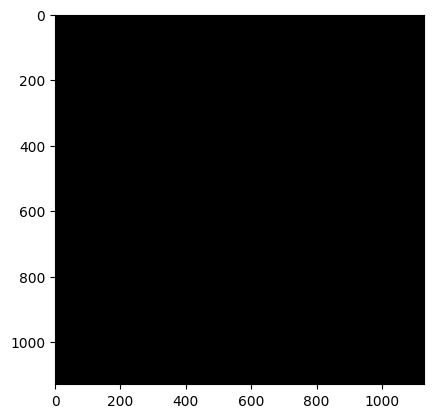

In [86]:
cell_mask = cv2.bitwise_not(white_mask)
plt.imshow(cell_mask, cmap='gray')

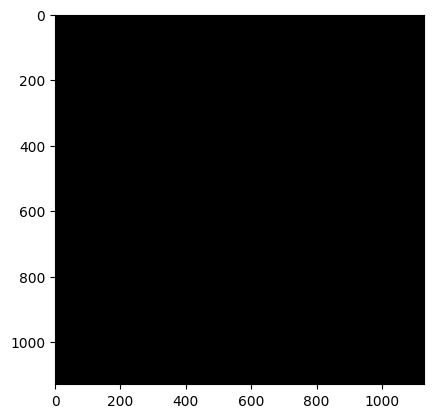

In [87]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (30, 30))
cell_mask = cv2.morphologyEx(cell_mask, cv2.MORPH_CLOSE, kernel)
plt.imshow(cell_mask, cmap='gray')

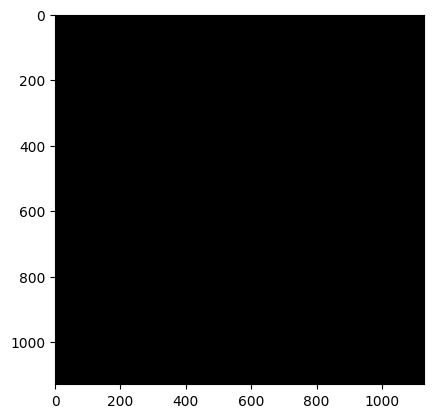

In [88]:
cell_mask = cv2.morphologyEx(cell_mask, cv2.MORPH_OPEN, kernel)
plt.imshow(cell_mask, cmap='gray')

In [89]:
import cv2
import numpy as np

def extract_nucleus_and_cell_contours(image_path, min_nucleus_area=50):
    image = cv2.imread(image_path)
    if image is None:
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    # ==== Usuwanie tła ====
    white_mask = cv2.inRange(image_rgb, np.array([220, 220, 220]), np.array([255, 255, 255]))
    not_white_mask = cv2.bitwise_not(white_mask)

    # ==== Segmentacja jądra ====
    gray_nonwhite = gray[not_white_mask > 0]
    if len(gray_nonwhite) == 0:
        return {
            'image_rgb': image_rgb,
            'nucleus_mask': np.zeros_like(gray),
            'nucleus_contour': np.zeros_like(gray),
            'cell_mask': np.zeros_like(gray),
            'cell_contour': np.zeros_like(gray)
        }

    mean_intensity = np.mean(gray_nonwhite)
    dynamic_thresh = int(mean_intensity * 0.8)

    dark_mask = cv2.inRange(gray, 0, dynamic_thresh)
    dark_mask = cv2.bitwise_and(dark_mask, dark_mask, mask=not_white_mask)

    kernel_nucleus = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    nucleus_clean = cv2.morphologyEx(dark_mask, cv2.MORPH_OPEN, kernel_nucleus)

    contours_nucleus, _ = cv2.findContours(nucleus_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_nucleus = np.zeros_like(gray)
    nucleus_contour_img = np.zeros_like(gray)

    if contours_nucleus:
        min_intensity = 999
        selected_contour = None

        for cnt in contours_nucleus:
            area = cv2.contourArea(cnt)
            if area < min_nucleus_area:
                continue

            temp_mask = np.zeros_like(gray)
            cv2.drawContours(temp_mask, [cnt], -1, 255, -1)
            mean_val = np.mean(gray[temp_mask == 255])

            if mean_val < min_intensity:
                min_intensity = mean_val
                selected_contour = cnt

        if selected_contour is not None:
            cv2.drawContours(mask_nucleus, [selected_contour], -1, 255, -1)
            nucleus_contour_img = cv2.Canny(mask_nucleus, 50, 150)

    # ==== Segmentacja całej komórki ====
    cell_mask_raw = cv2.bitwise_not(white_mask)

    # kontur komórki (opcjonalny, np. do wizualizacji)
    cell_blurred = cv2.GaussianBlur(cell_mask_raw, (3, 3), 0)
    cell_contour = cv2.Canny(cell_blurred, 30, 100)

    # oczyszczenie maski komórki
    kernel_cell = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (80, 80))
    cell_mask = cv2.morphologyEx(cell_mask_raw, cv2.MORPH_CLOSE, kernel_cell)
    cell_mask = cv2.morphologyEx(cell_mask, cv2.MORPH_OPEN, kernel_cell)

    # wypełnienie dziur wewnątrz komórki
    contours, hierarchy = cv2.findContours(cell_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    for i in range(len(contours)):
        if hierarchy[0][i][3] != -1:  # tylko dziury
            cv2.drawContours(cell_mask, contours, i, 255, -1)

    # ==== Zwracanie wyników jako słownik ====
    return {
        'image_rgb': image_rgb,
        'nucleus_mask': mask_nucleus,
        'nucleus_contour': nucleus_contour_img,
        'cell_mask': cell_mask,
        'cell_contour': cell_contour
    }


In [90]:
extracted_image, nucleus_mask, nucleus_contour, cell_mask, cell_contour = extract_nucleus_and_cell_contours(image_path)

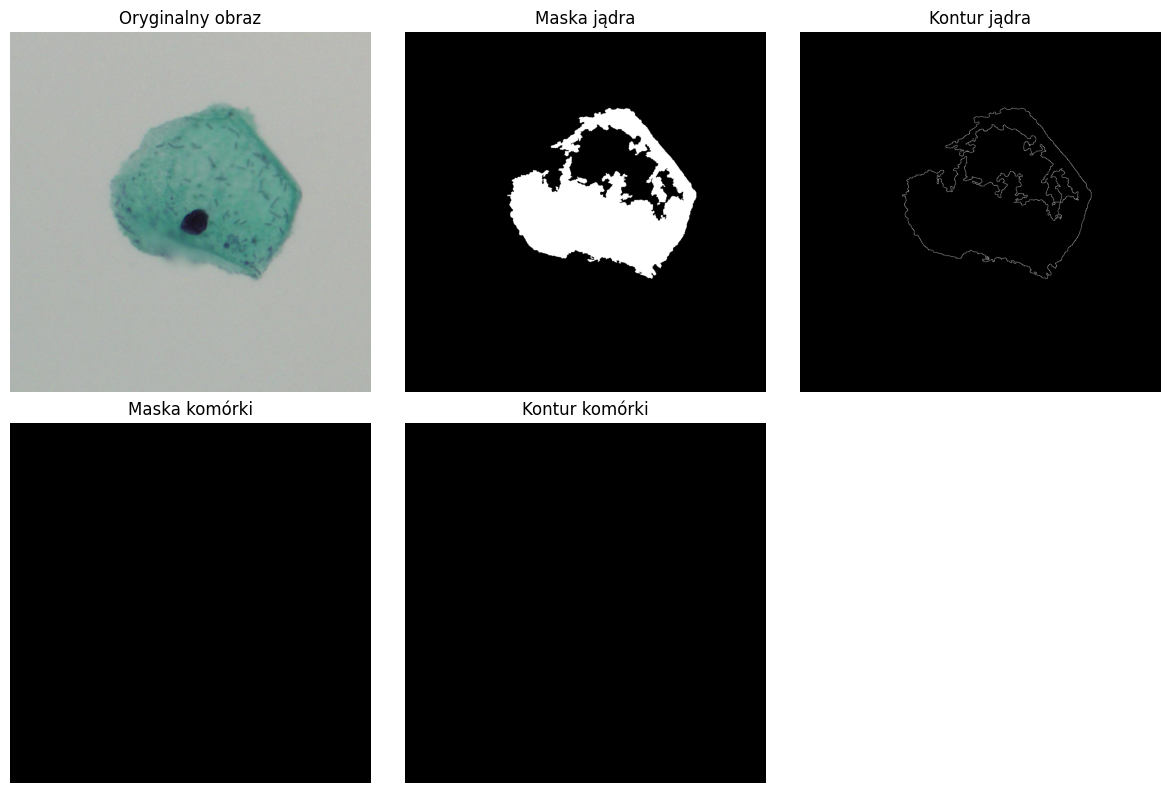

In [91]:
results = extract_nucleus_and_cell_contours(image_path)

# Wyświetlanie wyników
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(results['image_rgb'])
plt.title('Oryginalny obraz')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(results['nucleus_mask'], cmap='gray')
plt.title('Maska jądra')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(results['nucleus_contour'], cmap='gray')
plt.title('Kontur jądra')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(results['cell_mask'], cmap='gray')
plt.title('Maska komórki')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(results['cell_contour'], cmap='gray')
plt.title('Kontur komórki')
plt.axis('off')

plt.tight_layout()
plt.show()
